# Fos-sur-Mer: what is hydrogen storage worth, and what does doing without the gas reformer cost?

*POMMES case study · PERSEE, MINES Paris – PSL · a textbook case, not a forecast.*

The industrial zone of Fos-sur-Mer uses **83.5 kt of hydrogen a year** (refining, methanol), today made by a
steam-methane reformer (SMR) burning natural gas, plus some by-product hydrogen from a chlorine plant (KEM ONE,
43 MW). An electrolyser could make it instead, buying electricity at the **hourly** price. Two questions:

1. **What is a hydrogen storage worth** — the Manosque salt cavern, 110 km away — to that electrolyser, and how does
   that value depend on the electrolyser's investment cost (CAPEX)?
2. **What does it cost to do without the gas reformer** as a back-up, i.e. to impose 100 % electrolytic hydrogen?

**How.** Hourly French electricity prices come from a European POMMES model of the 2030 power system (16 zones,
11 weather years, three gas prices; T. Knibiehly, PhD, PERSEE). The hub itself is a one-node linear programme —
the *reduced model* — that chooses electrolyser and cavern sizes and their hourly operation at least annual cost.
It reproduces the full POMMES modelling of the Fos hub at every point POMMES solved (section 3). The equations
and costs live in `regles_parametriques/regles/cavite.py`; `fos_case.py` only reads the frozen data and calls them.

Assumptions, units and sources: `hypotheses.yaml`. Interactive version: `page.html`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fos_case as fc, analyse
pd.set_option("display.precision", 2)
print("demand:", round(fc.kt_par_an(fc.DEMANDE_FOS_MW), 1), "kt/yr =", round(fc.DEMANDE_FOS_MW, 1), "MW flat")

demand: 83.5 kt/yr = 317.7 MW flat


## 1. The electricity prices

What matters for storage is not the average price but the **spread** between cheap and expensive hours. The gas
price sets that spread: gas-fired plants set the price in expensive hours, renewables and nuclear in cheap ones.

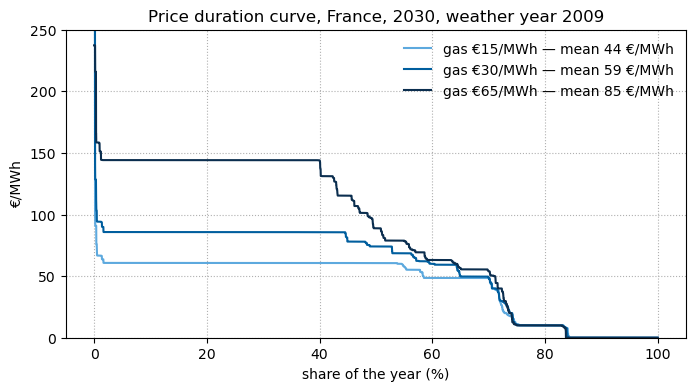

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for g, c in zip(fc.GAZ, ["#5DA9DE", "#005E9E", "#0B2E4F"]):
    p = np.sort(fc.prix("cy2009", g))[::-1]
    ax.plot(np.arange(len(p)) / len(p) * 100, p, color=c, label=f"gas €{g}/MWh — mean {p.mean():.0f} €/MWh")
ax.set(xlabel="share of the year (%)", ylabel="€/MWh", ylim=(0, 250), title="Price duration curve, France, 2030, weather year 2009")
ax.legend(frameon=False); ax.grid(ls=":")

In [3]:
tab = pd.DataFrame({(a, g): [fc.prix(a, g).mean()] for a in fc.ANNEES for g in fc.GAZ}).T[0].unstack()
tab.columns = [f"gas {g}" for g in tab.columns]
tab.round(1)   # mean French price (€/MWh) by weather year

,gas 15,gas 30,gas 65
cy1983,37.5,50.4,78.2
cy1985,43.6,58.1,90.1
cy1987,45.3,61.9,97.2
cy1990,36.2,48.5,75.2
cy1996,44.4,59.2,92.4
cy2000,37.1,48.1,73.3
cy2003,44.6,61.5,99.3
cy2009,43.7,58.6,85.4
cy2010,48.0,65.7,107.3
cy2012,42.5,57.0,88.2


## 2. One run of the reduced model

100 % electrolytic hydrogen, electrolyser at 1,350 €/kW_e (RTE reference), gas at €30/MWh, weather year 2009.
Without the cavern, the electrolyser follows the flat demand and pays the average price. With it, the
electrolyser is oversized and runs only in the cheapest hours; the cavern fills in spring and summer and empties
in winter.

solved in 10.2 s — value of the cavern: 0.442 €/kg (11.9 % of the cost of electrolytic H2 without it), cavern 200 GWh, electrolyser 1109 MW_e, running 45 % of the hours


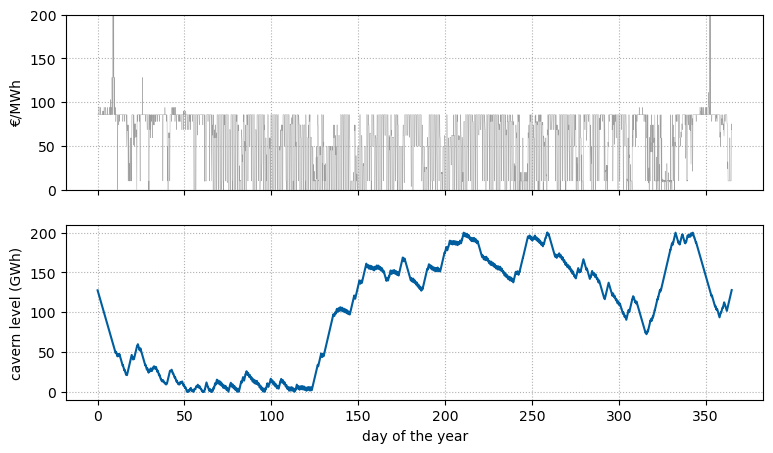

In [4]:
p = fc.prix("cy2009", 30)
par = fc.parametres(1350, 0.68)
res, sol = fc.cavite.valeur_lp(p, par, avec_solution=True)
print(f"solved in {sol.temps_s:.1f} s — value of the cavern: {res.valeur_eur_par_kg:.3f} €/kg "
      f"({100 * res.part_cout:.1f} % of the cost of electrolytic H2 without it), cavern {sol.E_mwh_h2 / 1e3:.0f} GWh, "
      f"electrolyser {sol.P_mw_h2 / 0.68:.0f} MW_e, running {100 * res.x:.0f} % of the hours")
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
j = np.arange(8760) / 24
ax[0].plot(j, p, lw=0.3, color="#9D9D9D"); ax[0].set(ylabel="€/MWh", ylim=(0, 200))
ax[1].plot(j, sol.s_mwh_h2 / 1e3, color="#005E9E"); ax[1].set(ylabel="cavern level (GWh)", xlabel="day of the year")
for a in ax: a.grid(ls=":")

## 3. Check: the reduced model against the full POMMES modelling

POMMES solved the Fos hub (without the steel plant) for three CAPEX levels, 11 weather years, with and without
the cavern, at several mandate levels. The reduced model is solved here on a few of those points and compared on
the **difference** of annual cost — the quantity both questions are about.

In [5]:
R = fc.pommes()
rows = []
for annee in ("cy1990", "cy2009", "cy2014"):
    for phi in (0.6, 1.0):
        q = R[(R.niveau_capex == "rte_ref") & (R.gaz_eur_mwh == 30) & (R.demande_europe == 1000) & (R.taxe_eur_t == 100)
              & (R.annee == annee)]
        tot = {s: q[(q.stockage == s) & (q.obligation == phi)].annualised_totex_eur.iloc[0] / 1e6 for s in ("no_storage", "manosque")}
        p = fc.prix(annee, 30)
        par = fc.parametres(1350, 0.68, part_min=phi, gaz=30)
        lp = {cav: fc.systeme(p, par, avec_cavite=cav).cout_meur_an for cav in (False, True)}
        rows.append({"year": annee, "mandate": phi, "value of cavern, POMMES (€m/yr)": tot["no_storage"] - tot["manosque"],
                     "value of cavern, reduced (€m/yr)": lp[False] - lp[True]})
pd.DataFrame(rows).round(3)

,year,mandate,"value of cavern, POMMES (€m/yr)","value of cavern, reduced (€m/yr)"
0,cy1990,0.6,21.19,21.19
1,cy1990,1.0,50.31,50.31
2,cy2009,0.6,12.02,12.02
3,cy2009,1.0,36.90,36.90
4,cy2014,0.6,18.61,18.61
5,cy2014,1.0,53.77,53.77


## 4. Question 1 — the value of storage, and the electrolyser's CAPEX

Grid of the reduced model (`grille.py stockage`): 7 CAPEX × 3 gas prices × 5 hydrogen volumes × 3 cavern caps ×
11 weather years. Dots: POMMES (mean of the 11 years).

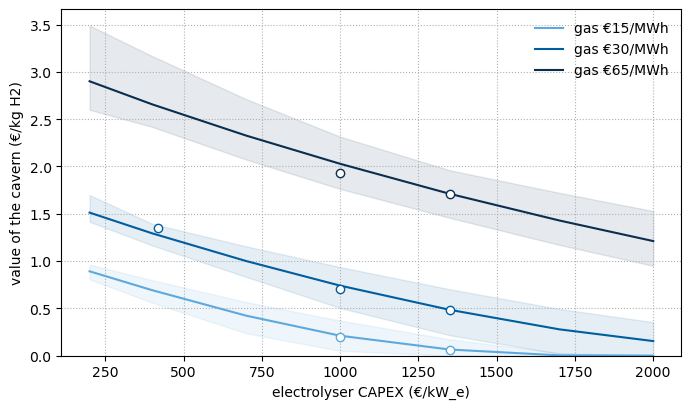

In [6]:
G = analyse.grille("stockage")
V = analyse.valeur_pommes()
fos = round(fc.kt_par_an(fc.DEMANDE_FOS_MW), 2)
g = G[(G.demande_kt == fos) & (G.volume_max_gwh == 200)]
fig, ax = plt.subplots(figsize=(8, 4.5))
for gaz, c in zip(fc.GAZ, ["#5DA9DE", "#005E9E", "#0B2E4F"]):
    s = g[g.gaz == gaz].groupby("capex").valeur_eur_par_kg.agg(["mean", "min", "max"])
    ax.plot(s.index, s["mean"], color=c, label=f"gas €{gaz}/MWh")
    ax.fill_between(s.index, s["min"], s["max"], color=c, alpha=0.1)
    pv = V[(V.obligation == 1) & (V.gaz_eur_mwh == gaz) & (V.demande_europe == 1000)].groupby("capex_eur_kw").valeur_eur_kg.mean()
    ax.scatter(pv.index, pv.values, facecolor="white", edgecolor=c, zorder=5)
ax.set(xlabel="electrolyser CAPEX (€/kW_e)", ylabel="value of the cavern (€/kg H2)", ylim=(0, None))
ax.legend(frameon=False); ax.grid(ls=":")

In [7]:
# The numbers quoted in the post (POMMES, mean and range over 11 weather years)
t = V[(V.demande_europe == 1000) & (V.obligation.isin([0, 1]))]
t.groupby(["obligation", "gaz_eur_mwh", "capex_eur_kw"]).agg(
    value_eur_kg=("valeur_eur_kg", "mean"), worst_year=("valeur_eur_kg", "min"), best_year=("valeur_eur_kg", "max"),
    share_of_cost=("part_cout", "mean"), value_meur_yr=("valeur_meur_an", "mean")).round(2)

value_eur_kg  worst_year  best_year  \
obligation gaz_eur_mwh capex_eur_kw                                        
0.0        30          417.0                 0.25        0.10       0.39   
                       1000.0                0.03       -0.00       0.08   
                       1350.0                0.00       -0.00       0.00   
1.0        15          1000.0                0.19        0.04       0.35   
                       1350.0                0.06       -0.00       0.17   
           20          1000.0                0.35        0.16       0.52   
                       1350.0                0.17        0.00       0.34   
           25          1000.0                0.52        0.29       0.71   
                       1350.0                0.32        0.09       0.52   
           30          417.0                 1.34        1.21       1.45   
                       1000.0                0.70        0.47       0.89   
                       1350.0                0.48        0.22       0.70   
           35          1000.0                0.87        0.67       1.07   
                       1350.0                0.65        0.36       0.89   
           40          1000.0                1.06        0.88       1.25   
                       1350.0                0.83        0.56       1.07   
           45          1000.0                1.24        1.08       1.42   
                       1350.0                1.01        0.78       1.25   
           50          1000.0                1.41        1.24       1.59   
                       1350.0                1.18        1.00       1.43   
           55          1000.0                1.59        1.39       1.77   
                       1350.0                1.36        1.16       1.61   
           60          1000.0                1.76        1.53       1.97   
                       1350.0                1.54        1.31       1.78   
           65          1000.0                1.93        1.68       2.20   
                       1350.0                1.71        1.46       1.96   

                                     share_of_cost  value_meur_yr  
obligation gaz_eur_mwh capex_eur_kw                                
0.0        30          417.0                  0.19          20.94  
                       1000.0                 0.02           2.15  
                       1350.0                 0.00           0.00  
1.0        15          1000.0                 0.08          16.27  
                       1350.0                 0.02           5.35  
           20          1000.0                 0.13          29.09  
                       1350.0                 0.06          13.78  
           25          1000.0                 0.17          43.50  
                       1350.0                 0.10          26.38  
           30          417.0                  0.42         112.29  
                       1000.0                 0.22          58.44  
                       1350.0                 0.14          40.41  
           35          1000.0                 0.25          73.05  
                       1350.0                 0.17          54.43  
           40          1000.0                 0.29          88.34  
                       1350.0                 0.21          69.50  
           45          1000.0                 0.32         103.28  
                       1350.0                 0.24          84.47  
           50          1000.0                 0.34         117.61  
                       1350.0                 0.27          98.90  
           55          1000.0                 0.37         132.38  
                       1350.0                 0.29         113.78  
           60          1000.0                 0.39         147.21  
                       1350.0                 0.32         128.56  
           65          1000.0                 0.41         161.37  
                       1350.0                 0.34         142.82

**Reading.** Under a 100 % mandate the cavern always has value, and that value falls as the electrolyser gets
dearer: a cheap electrolyser is oversized more, so it can shift more of its purchases to cheap hours. The gas price
matters as much as the CAPEX, although no gas is burnt at 100 %: it acts only through the spread of electricity
prices. Without a mandate, at the central CAPEX, the cavern is worth nothing: electrolysis is built in only 3 weather years out of 11, to make about 40 % of the hydrogen in cheap hours, and the existing gas reformer provides the flexibility.

### The volume of hydrogen

For the same cavern, a smaller demand can be shifted over longer periods (the cavern's autonomy grows), so the
value **per kg** rises; a larger one (Fos with a hydrogen-based steel plant, 287.5 kt/yr) fills the cavern in two
weeks. The model is homogeneous: only the ratio cap / demand matters (25 kt/yr with 100 GWh = 50 kt/yr with 200 GWh). Below: gas €30/MWh, 1,350 €/kW_e.

In [8]:
s = G[(G.gaz == 30) & (G.capex == 1350)].groupby(["demande_kt", "volume_max_gwh"]).valeur_eur_par_kg.mean().unstack()
s.columns = [f"cap {c:g} GWh" for c in s.columns]
s.round(2)   # €/kg by hydrogen demand (kt/yr)

,cap 100 GWh,cap 200 GWh,cap 400 GWh
demande_kt,,,
25.00,0.52,0.53,0.53
50.00,0.47,0.52,0.53
83.49,0.42,0.48,0.52
150.00,0.37,0.43,0.49
287.47,0.30,0.37,0.44


### A one-line rule

The *simplified model* of `regles/cavite.py` replaces the LP by a sort of hourly prices in windows as long as the
cavern's autonomy. It needs no solver (~1 ms) — how far is it from the LP?

In [9]:
e = (G.simplifie_eur_par_kg - G.valeur_eur_par_kg)
print(f"simplified − LP over {len(G)} cases: median {e.median():+.3f} €/kg, "
      f"median |error| {e.abs().median():.3f} €/kg, 90th pct |error| {e.abs().quantile(.9):.3f} €/kg")
G.assign(err=e).groupby(["demande_kt"]).err.describe()[["mean", "50%", "min", "max"]].round(3)

simplified − LP over 3465 cases: median -0.010 €/kg, median |error| 0.017 €/kg, 90th pct |error| 0.067 €/kg


,mean,50%,min,max
demande_kt,,,,
25.00,-1.60e-02,-1.30e-02,-0.18,0.16
50.00,-1.40e-02,-1.10e-02,-0.18,0.16
83.49,-1.40e-02,-1.20e-02,-0.16,0.17
150.00,-9.00e-03,-7.00e-03,-0.18,0.16
287.47,-7.00e-03,-5.00e-03,-0.15,0.14


## 5. Question 2 — the cost of doing without the reformer

A mandate fixes a minimum electrolytic share of the hydrogen served. The cost of the mandate is measured against
the **unconstrained hub** (the least-cost hub with no mandate, carbon tax of €100/t included), and read **excluding
the carbon tax** — a transfer, not a cost to society.

⚠️ The chlorine by-product (43 MW, 13.5 % of the hydrogen) emits nothing in the model but counts as
non-electrolytic. At an 86.5 % mandate the reformer no longer runs; beyond, electrolysis replaces chlorine and
avoids no CO₂.

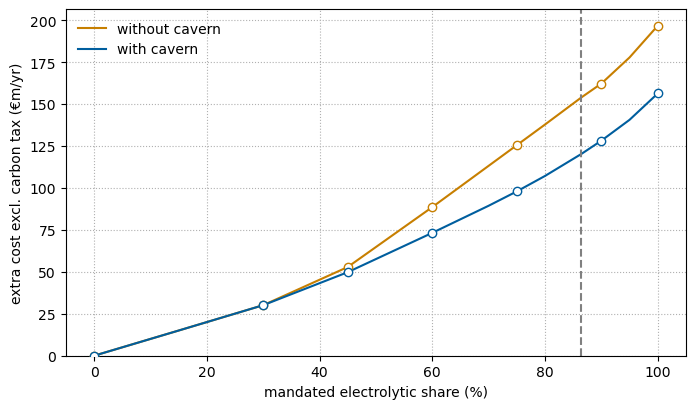

In [10]:
O = analyse.obligation_pommes()
Gh = analyse.obligation_reduit()
fig, ax = plt.subplots(figsize=(8, 4.5))
for cav, c in ((False, "#C77F00"), (True, "#005E9E")):
    s = Gh[(Gh.niveau_capex == "rte_ref") & (Gh.gaz == 30) & (Gh.avec_cavite == cav)].groupby("obligation").surcout_hors_taxe_meur_an.mean()
    ax.plot(100 * s.index, s.values, color=c, label="with cavern" if cav else "without cavern")
    po = O[(O.niveau_capex == "rte_ref") & (O.avec_cavite == cav)].groupby("obligation").surcout_hors_taxe_meur_an.mean()
    ax.scatter(100 * po.index, po.values, facecolor="white", edgecolor=c, zorder=5)
ax.axvline(100 * (1 - fc.CHLORE_MW / fc.DEMANDE_FOS_MW), ls="--", color="grey")
ax.set(xlabel="mandated electrolytic share (%)", ylabel="extra cost excl. carbon tax (€m/yr)", ylim=(0, None))
ax.legend(frameon=False); ax.grid(ls=":")

In [11]:
# Steps of the mandate: marginal abatement cost (€/tCO2), reduced model, 1,350 €/kW_e
m = analyse.marches(Gh[Gh.niveau_capex == "rte_ref"], ["gaz", "avec_cavite"])
m.pivot_table(index="obligation", columns=["gaz", "avec_cavite"], values="abattement_marginal_eur_t").round(0)

gaz              15              30               65        
avec_cavite   False   True    False   True     False   True 
obligation                                                  
0.15          187.0   187.0   153.0   153.0      NaN     NaN
0.30          187.0   187.0   154.0   154.0    217.0   106.0
0.45          195.0   195.0   205.0   177.0    258.0   106.0
0.60          220.0   209.0   265.0   174.0    458.0   110.0
0.70          222.0   209.0   274.0   180.0    401.0   154.0
0.75          222.0   210.0   274.0   195.0    398.0   227.0
0.80          222.0   214.0   274.0   207.0    398.0   246.0
0.86          265.0   240.0   336.0   230.0    416.0   337.0
0.90            NaN  4794.0     NaN  3215.0    458.0   758.0
0.95         5016.0     NaN  2286.0     NaN   1405.0  2826.0
1.00         4231.0  8214.0  8829.0     NaN  13847.0     NaN

In [12]:
# Same at the POMMES points (gas 30), average and marginal abatement cost
analyse._arrondi(analyse.marches(O, ["niveau_capex", "avec_cavite"]))

,niveau_capex,avec_cavite,obligation,surcout_hors_taxe_meur_an,evite_kt,marche_meur_an,marche_evite_kt,abattement_marginal_eur_t,abattement_moyen_eur_t
0,rte_favorable,False,0.00,-9.7,-118.2,NaN,NaN,NaN,NaN
1,rte_favorable,False,0.30,2.3,-17.1,12.0,101.1,118.6,NaN
2,rte_favorable,False,0.45,22.7,86.0,20.4,103.1,197.9,264.2
3,rte_favorable,False,0.60,55.7,215.8,33.0,129.8,254.3,258.2
4,rte_favorable,False,0.75,90.4,350.5,34.7,134.7,257.3,257.9
5,rte_favorable,False,0.90,123.8,448.6,33.4,98.1,340.9,276.0
6,rte_favorable,False,1.00,156.6,458.4,32.8,9.8,3354.1,341.7
7,rte_favorable,True,0.00,0.0,0.0,NaN,NaN,NaN,NaN
8,rte_favorable,True,0.30,11.8,101.1,11.8,101.1,116.3,116.3
9,rte_favorable,True,0.45,23.4,185.3,11.6,84.1,138.4,126.4


## 6. What this case does not say — and how to go further

* Prices are **exogenous**: the electrolyser does not move them. The cavern's cap (200 GWh) is declared, not
  geological; lifted, POMMES builds much more, so the value here is a lower bound.
* The hub is **isolated**: a hydrogen network (to Lyon, Spain) would change the value of local storage.
* The EU hourly-correlation rule for renewable hydrogen (RFNBO) is not modelled.
* One European power system (2030); the weather years change, the fleet does not. Replaying the case with the
  TYNDP 2026 scenarios is a natural next step.

These are the kind of mini-projects a group carries out during the course.